In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import seaborn as sns
import pandas as pd
import numpy as np

import scipy.stats
from scipy.stats import ttest_ind

import scienceplots
import warnings


import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

In [2]:
measure_col = 'periods'
group_cols = ['Condition', 'Exp']

In [3]:
def remove_outliers_tukey(df, measure_col, group_cols, k=1.5):
    def tukey_fence(group):
        q1 = group[measure_col].quantile(0.25)
        q3 = group[measure_col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr
        return group[(group[measure_col] >= lower) & (group[measure_col] <= upper)]
    
    return df.groupby(group_cols, group_keys=False).apply(tukey_fence)

In [4]:
# Superplots!! For conditions with Control
def superplot(data, group_cols, measure_col, ttest=False, **kwargs):
    group_condition, group_replicate = group_cols

    # Ensure 'Control' is first and other conditions follow
    all_conditions = sorted([c for c in data[group_condition].unique() if c != 'Control'])
    ordered_conditions = ['Control'] + all_conditions
    data[group_condition] = pd.Categorical(data[group_condition], categories=ordered_conditions, ordered=True)

    # Calculate the average for each replicate within each condition
    replicate_averages = data.groupby(group_cols, as_index=False).agg({measure_col: 'mean'})

    # Compute mean and SEM across replicates
    condition_stats = replicate_averages.groupby(group_condition).agg(
        mean_measure=(measure_col, 'mean'),
        sem_measure=(measure_col, lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
    ).reset_index()

    # Create plot
    with plt.style.context('science'):
        plt.figure(figsize=(8, 6))

        # Raw data swarm plot
        sns.swarmplot(
            x=group_condition, y=measure_col, hue=group_replicate,
            data=data, size=5, edgecolor="k", linewidth=1.5, alpha=0.4, legend=False
        )

        # Replicate means
        sns.swarmplot(
            x=group_condition, y=measure_col, hue=group_replicate,
            data=replicate_averages, size=15, edgecolor="k", linewidth=2, dodge=True, alpha=0.6, legend=False
        )

        # Overlay mean and SEM whiskers for each condition and capture first for legend
        for i, row in condition_stats.iterrows():
            if i == 0:
                got_error = plt.errorbar(
                    x=i,
                    y=row['mean_measure'],
                    yerr=row['sem_measure'],
                    fmt='_',
                    color='black',
                    capsize=5,
                    elinewidth=2,
                    markersize=30
                )
            else:
                plt.errorbar(
                    x=i,
                    y=row['mean_measure'],
                    yerr=row['sem_measure'],
                    fmt='_',
                    color='black',
                    capsize=5,
                    elinewidth=2,
                    markersize=30
                )
        _, caplines, barlinecols = got_error
        custom_sem_handle = barlinecols[0]

        # p-values
        
        if ttest==True:
            try:
                control_vals = replicate_averages[replicate_averages[group_condition] == 'Control'][measure_col].values
                y_max = data[measure_col].max() + 2
                for i, cond in enumerate(all_conditions, start=1):
                    treatment_vals = replicate_averages[replicate_averages[group_condition] == cond][measure_col].values
                    stat, pval = ttest_ind(treatment_vals, control_vals, equal_var=False)
                    annotation = f"p = {pval:.4f}"
                    plt.text(i, y_max, annotation, ha='center', va='bottom', color='black')
            except Exception as e:
                warnings.warn(f"Could not compute test annotations: {e}")

        # Dots format
        custom_dot = Line2D([], [], marker='o', color='w', markerfacecolor='gray',
                            markeredgecolor='k', markersize=15, linewidth=2, alpha=0.6)

        # Legends format
        plt.legend(
            [custom_dot, got_error],
            [
                '\u00A0\u00A0\u00A0Mean of replicate N \nfor condition M',
                f'{measure_col.replace("_", " ").capitalize()} (mean ± SEM)\nacross replicates for condition M'
            ],
            loc='upper left',
            bbox_to_anchor=(0.02, 0.98),
            frameon=True,
            title=""
        )

        if 'xticks_fontsize' in list(kwargs.keys()):
            plt.xticks(fontsize=kwargs.get('xticks_fontsize'))
        else:
            plt.xticks(fontsize=14)
        if 'yticks_fontsize' in list(kwargs.keys()):
            plt.yticks(fontsize=kwargs.get('yticks_fontsize'))
        else:
            plt.yticks(fontsize=14)
        if ('xlabel' and 'xlabel_fontsize') in list(kwargs.keys()):
            plt.xlabel(kwargs.get('xlabel'), fontsize=kwargs.get('xlabel_fontsize'))
        if ('ylabel' and 'ylabel_fontsize') in list(kwargs.keys()):
            plt.ylabel(kwargs.get('ylabel'), fontsize=kwargs.get('ylabel_fontsize'))
        if ('title' and 'title_size') in list(kwargs.keys()):
            plt.title(kwargs.get('title'), fontsize=kwargs.get('title_size'))
        elif 'title' in list(kwargs.keys()):
            plt.title(kwargs['title'], fontsize=18)
        else:
            pass
        # Ticks
        plt.tick_params(axis='x', which='both', bottom=False, top=False)
        plt.tick_params(axis='y', which='both', left=True, right=True)

        # Grid
        plt.grid(False)
        plt.tight_layout()

        # Saving
        if ('save_path' in list(kwargs.keys()) and (kwargs.get('save_path') is not None)):
            plt.savefig(kwargs.get('save_path'))
        
        plt.show()

        
        

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from scipy.stats import ttest_ind
import warnings

def superplot(data, group_cols, measure_col, ttest=False, category_order=None, **kwargs):
    group_condition, group_replicate = group_cols

    # Ensure clean columns
    data = data.reset_index()
    data[group_condition] = data[group_condition].astype(str)

    # Determine category order
    if category_order is None:
        ordered_conditions = sorted(data[group_condition].unique())
    else:
        ordered_conditions = category_order

    # Apply categorical order to main data
    data[group_condition] = pd.Categorical(data[group_condition], categories=ordered_conditions, ordered=True)

    # Filter out empty groups (if any)
    data = data.groupby(group_cols, observed=True).filter(lambda g: len(g) > 0)

    # Always compute replicate means
    replicate_averages = data.groupby(group_cols, as_index=False, observed=True).agg({measure_col: 'mean'})

    # Apply category order to replicate_averages
    replicate_averages[group_condition] = pd.Categorical(
        replicate_averages[group_condition], categories=ordered_conditions, ordered=True
    )

    # Compute condition-level summary
    if data[group_replicate].nunique() == 1:
        # Only one replicate → no SEM
        condition_stats = replicate_averages.groupby(group_condition, observed=True).agg(
            mean_measure=(measure_col, 'mean'),
            sem_measure=(measure_col, lambda x: np.nan)
        ).reset_index()
    else:
        condition_stats = replicate_averages.groupby(group_condition, observed=True).agg(
            mean_measure=(measure_col, 'mean'),
            sem_measure=(measure_col, lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
        ).reset_index()

    # Apply category order to condition_stats
    condition_stats[group_condition] = pd.Categorical(
        condition_stats[group_condition], categories=ordered_conditions, ordered=True
    )

    # Plot
    with plt.style.context('science'):
        plt.figure(figsize=(8, 6))

        # Raw data
        sns.swarmplot(
            x=group_condition, y=measure_col, hue=group_replicate,
            data=data, size=5, edgecolor="k", linewidth=1.5, alpha=0.4, legend=False
        )

        # Replicate means
        sns.swarmplot(
            x=group_condition, y=measure_col, hue=group_replicate,
            data=replicate_averages, size=15, edgecolor="k", linewidth=2, dodge=True, alpha=0.6, legend=False
        )

        # Error bars (mean ± SEM)
        for i, row in condition_stats.iterrows():
            err = row['sem_measure'] if not np.isnan(row['sem_measure']) else 0
            if i == 0:
                got_error = plt.errorbar(
                    x=i, y=row['mean_measure'], yerr=err,
                    fmt='_', color='black', capsize=5, elinewidth=2, markersize=30
                )
            else:
                plt.errorbar(
                    x=i, y=row['mean_measure'], yerr=err,
                    fmt='_', color='black', capsize=5, elinewidth=2, markersize=30
                )
        _, caplines, barlinecols = got_error
        custom_sem_handle = barlinecols[0]

        # Optional t-test (only if 2 conditions)
        if ttest and len(ordered_conditions) == 2:
            try:
                cond1, cond2 = ordered_conditions
                vals1 = replicate_averages[replicate_averages[group_condition] == cond1][measure_col].values
                vals2 = replicate_averages[replicate_averages[group_condition] == cond2][measure_col].values
                stat, pval = ttest_ind(vals1, vals2, equal_var=False)
                y_max = data[measure_col].max() + 2
                annotation = f"p = {pval:.4f}"
                plt.text(0.5, y_max, annotation, ha='center', va='bottom', color='black')
            except Exception as e:
                warnings.warn(f"Could not compute t-test: {e}")

        # Custom legend
        custom_dot = Line2D([], [], marker='o', color='w', markerfacecolor='gray',
                            markeredgecolor='k', markersize=15, linewidth=2, alpha=0.6)

        plt.legend(
            [custom_dot, custom_sem_handle],
            [
                '\u00A0\u00A0\u00A0Mean of replicate N \nfor condition M',
                f'{measure_col.replace("_", " ").capitalize()} (mean ± SEM)\nacross replicates for condition M'
            ],
            loc='upper center',
            frameon=True,
            title=""
        )

        # Labels and formatting
        plt.xticks(fontsize=kwargs.get('xticks_fontsize', 14))
        plt.yticks(fontsize=kwargs.get('yticks_fontsize', 14))
        plt.xlabel(kwargs.get('xlabel', ''), fontsize=kwargs.get('xlabel_fontsize', 14))
        plt.ylabel(kwargs.get('ylabel', ''), fontsize=kwargs.get('ylabel_fontsize', 14))
        if 'title' in kwargs:
            plt.title(kwargs['title'], fontsize=kwargs.get('title_fontsize', 18))

        plt.tick_params(axis='x', which='both', bottom=False, top=False)
        plt.tick_params(axis='y', which='both', left=True, right=True)
        plt.grid(False)
        plt.tight_layout()

        # Save
        if kwargs.get('save_path') is not None:
            plt.savefig(kwargs['save_path'])

        plt.show()


In [6]:
ridges_wt1 = pd.read_csv(r'H:/PROJECTS-03/Pablo/oscillating/hoff-mAID-xxx_injected/analysis/ridges_hoff-mAIDXXX_injected', index_col=0)
peak_data_wt1 = pd.read_csv(r'H:/PROJECTS-03/Pablo/oscillating/hoff-mAID-xxx_injected/analysis/peak_data_hoff-maidXXX_injected', index_col=0)

ridges_wt2 = pd.read_csv(r'H:/PROJECTS-03/Pablo/oscillating/hoff-mAID-xxx_injected/analysis/ridges_hoff-maidwt2', index_col=0)
peak_data_wt2 = pd.read_csv(r'H:/PROJECTS-03/Pablo/oscillating/hoff-mAID-xxx_injected/analysis/peak_data_hoff-maidWT2', index_col=0)

ridges_wt3 = pd.read_csv(r'H:/PROJECTS-03/Pablo/oscillating/hoff_hoff-maid_july/analysis/ridges_hoff-hoff-maid', index_col=0)
peak_data_wt3 = pd.read_csv(r'H:/PROJECTS-03/Pablo/oscillating/hoff_hoff-maid_july/analysis/peak_data_hoff_hoff_mAID', index_col=0)

ridges_wt4 = pd.read_csv(r'H:/PROJECTS-03/Pablo/oscillating/hoff_hoff-maid_july/analysis/ridges_hoff-hoff-maidXXX', index_col=0)
peak_data_wt4 = pd.read_csv(r'H:/PROJECTS-03/Pablo/oscillating/hoff_hoff-maid_july/analysis/peak_data_hoff_hoff_mAIDXXX', index_col=0)

In [8]:
peak_data_wt1

,Exp,Signal,Critical Point pos,Critical Point heights,Absolute Critical Point heights,Threshold,Critical Point proms,Beginning of oscillation,End of oscillation,ToD,Sample rate,Is peak,Is trough,Condition
0,hoff-maidXXX_injected,hoff-maidxxx_injected_xy001_2,7.0,0.088189,187.188843,0.01,0.03,0.0,88.0,0,8,True,False,Hoff-mAIDXXX
1,hoff-maidXXX_injected,hoff-maidxxx_injected_xy001_2,11.0,0.044860,130.083492,0.01,0.03,0.0,88.0,0,8,False,True,Hoff-mAIDXXX
2,hoff-maidXXX_injected,hoff-maidxxx_injected_xy001_2,21.0,0.705366,1000.605991,0.01,0.03,0.0,88.0,0,8,True,False,Hoff-mAIDXXX
3,hoff-maidXXX_injected,hoff-maidxxx_injected_xy001_2,32.0,0.092125,192.376600,0.01,0.03,0.0,88.0,0,8,False,True,Hoff-mAIDXXX
4,hoff-maidXXX_injected,hoff-maidxxx_injected_xy001_2,41.0,0.741411,1048.112084,0.01,0.03,0.0,88.0,0,8,True,False,Hoff-mAIDXXX
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
322,hoff-maidXXX_injected,hoff-maidxxx_injected_xy097_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8,False,False,Unknown
323,hoff-maidXXX_injected,hoff-maidxxx_injected_xy098_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8,False,False,Unknown
324,hoff-maidXXX_injected,hoff-maidxxx_injected_xy099_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8,False,False,Unknown
325,hoff-maidXXX_injected,hoff-maidxxx_injected_xy100_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8,False,False,Unknown


In [11]:
value_map = peak_data_wt1.drop_duplicates('Signal').set_index('Signal')['Condition']

In [12]:
value_map

Signal
hoff-hoff-maid001xxx_xy003_0         HoffXXX
hoff-hoff-maid001xxx_xy003_1         HoffXXX
hoff-hoff-maid001xxx_xy005_0         HoffXXX
hoff-hoff-maid001xxx_xy007_0         HoffXXX
hoff-hoff-maid001xxx_xy008_0         HoffXXX
hoff-hoff-maid001xxx_xy013_0         HoffXXX
hoff-hoff-maid001xxx_xy017_0         HoffXXX
hoff-hoff-maid001xxx_xy017_1         HoffXXX
hoff-hoff-maid001xxx_xy018_0         HoffXXX
hoff-hoff-maid001xxx_xy018_1         HoffXXX
hoff-hoff-maid001xxx_xy019_0         HoffXXX
hoff-hoff-maid001xxx_xy020_0         HoffXXX
hoff-hoff-maid001xxx_xy021_0         HoffXXX
hoff-hoff-maid001xxx_xy022_0         HoffXXX
hoff-hoff-maid001xxx_xy024_0         HoffXXX
hoff-hoff-maid001xxx_xy025_0         HoffXXX
hoff-hoff-maid001xxx_xy025_1         HoffXXX
hoff-hoff-maid001xxx_xy030_0         HoffXXX
hoff-hoff-maid001xxx_xy033_0         HoffXXX
hoff-hoff-maid001xxx_xy035_1         HoffXXX
hoff-hoff-maid001xxx_xy039_1         HoffXXX
hoff-hoff-maid001xxx_xy039_2         HoffXXX
hof

In [9]:
ridges_wt1['Exp']=peak_data_wt1['Exp'].iloc[0]
value_map = peak_data_wt1.drop_duplicates('Signal').set_index('Signal')['Condition']
ridges_wt1['Condition']=ridges_wt1['Signal'].map(value_map)

In [37]:
ridges_wt1

,time,periods,phase,amplitude,power,frequencies,Signal,Exp,Condition
0,27,124.826827,5.644560,0.955457,1.067699,0.008011,hoff-hoff-maid001xxx_xy003_0,hoff_hoff_mAIDXXX,HoffXXX
1,36,124.826827,6.098067,1.008840,1.190341,0.008011,hoff-hoff-maid001xxx_xy003_0,hoff_hoff_mAIDXXX,HoffXXX
2,45,124.362362,0.253223,1.062700,1.315917,0.008041,hoff-hoff-maid001xxx_xy003_0,hoff_hoff_mAIDXXX,HoffXXX
3,54,124.362362,0.707623,1.116102,1.451493,0.008041,hoff-hoff-maid001xxx_xy003_0,hoff_hoff_mAIDXXX,HoffXXX
4,63,124.594595,1.167926,1.168005,1.592600,0.008026,hoff-hoff-maid001xxx_xy003_0,hoff_hoff_mAIDXXX,HoffXXX
...,...,...,...,...,...,...,...,...,...
1700,594,96.030030,4.077520,1.143412,1.384297,0.010413,hoff-hoff-maid001xxx_xy110_0,hoff_hoff_mAIDXXX,Hoff-mAIDXXX
1701,603,95.565566,4.674603,1.110380,1.299159,0.010464,hoff-hoff-maid001xxx_xy110_0,hoff_hoff_mAIDXXX,Hoff-mAIDXXX
1702,612,95.101101,5.275988,1.076240,1.214565,0.010515,hoff-hoff-maid001xxx_xy110_0,hoff_hoff_mAIDXXX,Hoff-mAIDXXX
1703,621,94.636637,5.881265,1.041110,1.131018,0.010567,hoff-hoff-maid001xxx_xy110_0,hoff_hoff_mAIDXXX,Hoff-mAIDXXX


In [11]:
ridges_wt2['Exp']=peak_data_wt2['Exp'].iloc[0]
value_map = peak_data_wt2.drop_duplicates('Signal').set_index('Signal')['Condition']
ridges_wt2['Condition']=ridges_wt2['Signal'].map(value_map)

In [13]:
ridges_wt2

,time,periods,phase,amplitude,power,frequencies,Signal,Exp,Condition
0,0,138.036036,4.799701,1.034140,2.456131,0.007244,hoff-maidwt2_xy02_0,hoff-maidWT2,Hoff-mAID
1,8,139.909910,5.216509,1.128858,2.966381,0.007147,hoff-maidwt2_xy02_0,hoff-maidWT2,Hoff-mAID
2,16,143.657658,5.670431,1.248817,3.727575,0.006961,hoff-maidwt2_xy02_0,hoff-maidWT2,Hoff-mAID
3,24,147.171171,6.100409,1.360416,4.531756,0.006795,hoff-maidwt2_xy02_0,hoff-maidWT2,Hoff-mAID
4,32,148.342342,0.178013,1.436818,5.095286,0.006741,hoff-maidwt2_xy02_0,hoff-maidWT2,Hoff-mAID
...,...,...,...,...,...,...,...,...,...
1657,464,154.900901,2.577128,1.575348,5.080135,0.006456,hoff-maidwt2_xy42_1,hoff-maidWT2,Hoff-mAID
1658,472,155.603604,2.877901,1.519681,4.748902,0.006427,hoff-maidwt2_xy42_1,hoff-maidWT2,Hoff-mAID
1659,480,156.306306,3.174848,1.457588,4.388487,0.006398,hoff-maidwt2_xy42_1,hoff-maidWT2,Hoff-mAID
1660,488,156.540541,3.483816,1.385618,3.971752,0.006388,hoff-maidwt2_xy42_1,hoff-maidWT2,Hoff-mAID


In [14]:
ridges_wt3['Exp']=peak_data_wt3['Exp'].iloc[0]
value_map = peak_data_wt3.drop_duplicates('Signal').set_index('Signal')['Condition']
ridges_wt3['Condition']=ridges_wt3['Signal'].map(value_map)

In [15]:
ridges_wt3

,time,periods,phase,amplitude,power,frequencies,Signal,Exp,Condition
0,0.00,155.492993,0.242990,0.805364,2.916602,0.006431,hoff-hoff-maid_xy003_0,hoff_hoff_mAID,Hoff
1,11.25,154.126627,0.653224,0.869839,3.372387,0.006488,hoff-hoff-maid_xy003_0,hoff_hoff_mAID,Hoff
2,22.50,153.671171,1.100843,0.941758,3.941425,0.006507,hoff-hoff-maid_xy003_0,hoff_hoff_mAID,Hoff
3,33.75,153.898899,1.568352,1.012641,4.563824,0.006498,hoff-hoff-maid_xy003_0,hoff_hoff_mAID,Hoff
4,45.00,153.671171,2.018149,1.080384,5.187174,0.006507,hoff-hoff-maid_xy003_0,hoff_hoff_mAID,Hoff
...,...,...,...,...,...,...,...,...,...
1767,517.50,168.245746,2.109202,1.276462,9.916833,0.005944,hoff-hoff-maid_xy117_0,hoff_hoff_mAID,Hoff-mAID
1768,528.75,171.661662,2.478678,1.222659,9.283188,0.005825,hoff-hoff-maid_xy117_0,hoff_hoff_mAID,Hoff-mAID
1769,540.00,174.166667,2.843259,1.178797,8.755011,0.005742,hoff-hoff-maid_xy117_0,hoff_hoff_mAID,Hoff-mAID
1770,551.25,175.077578,3.223259,1.132587,8.124323,0.005712,hoff-hoff-maid_xy117_0,hoff_hoff_mAID,Hoff-mAID


In [16]:
ridges_wt4['Exp']=peak_data_wt4['Exp'].iloc[0]
value_map = peak_data_wt4.drop_duplicates('Signal').set_index('Signal')['Condition']
ridges_wt4['Condition']=ridges_wt4['Signal'].map(value_map)

In [17]:
ridges_wt4

,time,periods,phase,amplitude,power,frequencies,Signal,Exp,Condition
0,27,124.826827,5.644560,0.955457,1.067699,0.008011,hoff-hoff-maid001xxx_xy003_0,hoff_hoff_mAIDXXX,HoffXXX
1,36,124.826827,6.098067,1.008840,1.190341,0.008011,hoff-hoff-maid001xxx_xy003_0,hoff_hoff_mAIDXXX,HoffXXX
2,45,124.362362,0.253223,1.062700,1.315917,0.008041,hoff-hoff-maid001xxx_xy003_0,hoff_hoff_mAIDXXX,HoffXXX
3,54,124.362362,0.707623,1.116102,1.451493,0.008041,hoff-hoff-maid001xxx_xy003_0,hoff_hoff_mAIDXXX,HoffXXX
4,63,124.594595,1.167926,1.168005,1.592600,0.008026,hoff-hoff-maid001xxx_xy003_0,hoff_hoff_mAIDXXX,HoffXXX
...,...,...,...,...,...,...,...,...,...
1700,594,96.030030,4.077520,1.143412,1.384297,0.010413,hoff-hoff-maid001xxx_xy110_0,hoff_hoff_mAIDXXX,Hoff-mAIDXXX
1701,603,95.565566,4.674603,1.110380,1.299159,0.010464,hoff-hoff-maid001xxx_xy110_0,hoff_hoff_mAIDXXX,Hoff-mAIDXXX
1702,612,95.101101,5.275988,1.076240,1.214565,0.010515,hoff-hoff-maid001xxx_xy110_0,hoff_hoff_mAIDXXX,Hoff-mAIDXXX
1703,621,94.636637,5.881265,1.041110,1.131018,0.010567,hoff-hoff-maid001xxx_xy110_0,hoff_hoff_mAIDXXX,Hoff-mAIDXXX


In [18]:
agg_ridges1 = ridges_wt1.groupby('Signal').agg(periods=('periods', 'mean'),
                                 Signal=('Signal', 'first'),
                                 Exp=('Exp', 'first'),
                                 Condition=('Condition', 'first'))

In [19]:
agg_ridges2 = ridges_wt2.groupby('Signal').agg(periods=('periods', 'mean'),
                                 Signal=('Signal', 'first'),
                                 Exp=('Exp', 'first'),
                                 Condition=('Condition', 'first'))

In [20]:
agg_ridges3 = ridges_wt3.groupby('Signal').agg(periods=('periods', 'mean'),
                                 Signal=('Signal', 'first'),
                                 Exp=('Exp', 'first'),
                                 Condition=('Condition', 'first'))

In [21]:
agg_ridges4 = ridges_wt4.groupby('Signal').agg(periods=('periods', 'mean'),
                                 Signal=('Signal', 'first'),
                                 Exp=('Exp', 'first'),
                                 Condition=('Condition', 'first'))

In [138]:
ridges_total = pd.concat([agg_ridges1, agg_ridges2, agg_ridges3, agg_ridges4], ignore_index=True)

In [139]:
ridges_total['Condition'].unique()

array(['Hoff-mAIDXXX', 'Hoff-mAID', 'Hoff', 'HoffXXX'], dtype=object)

In [140]:
ridges_total = ridges_total.loc[(ridges_total['Condition']=='Hoff') | (ridges_total['Condition']=='Hoff-mAID'),:]

In [6]:
hl_df = pd.read_csv('decay_total', index_col=0)[['Condition','Exp','half-life']]

In [131]:
hl_cleaned = remove_outliers_tukey(ridges_total, measure_col=measure_col, group_cols=group_cols, k=1.5)

C:\Users\pperez\AppData\Local\Temp\3\ipykernel_38928\977485057.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols, group_keys=False).apply(tukey_fence)


In [26]:
ridges_total.iloc[:,[0,2,3]]

,Signal,periods,Exp,Condition
0,hoff-hoff-maid001xxx_xy003_0,173.040258,hoff_hoff_mAIDXXX,HoffXXX
1,hoff-hoff-maid001xxx_xy003_1,147.322796,hoff_hoff_mAIDXXX,HoffXXX
2,hoff-hoff-maid001xxx_xy005_0,157.694260,hoff_hoff_mAIDXXX,HoffXXX
3,hoff-hoff-maid001xxx_xy007_0,146.266682,hoff_hoff_mAIDXXX,HoffXXX
4,hoff-hoff-maid001xxx_xy008_0,120.782783,hoff_hoff_mAIDXXX,HoffXXX
5,hoff-hoff-maid001xxx_xy013_0,188.173145,hoff_hoff_mAIDXXX,HoffXXX
6,hoff-hoff-maid001xxx_xy017_0,133.317378,hoff_hoff_mAIDXXX,HoffXXX
7,hoff-hoff-maid001xxx_xy021_0,144.606955,hoff_hoff_mAIDXXX,HoffXXX
8,hoff-hoff-maid001xxx_xy022_0,118.417217,hoff_hoff_mAIDXXX,HoffXXX
9,hoff-hoff-maid001xxx_xy024_0,186.506361,hoff_hoff_mAIDXXX,HoffXXX


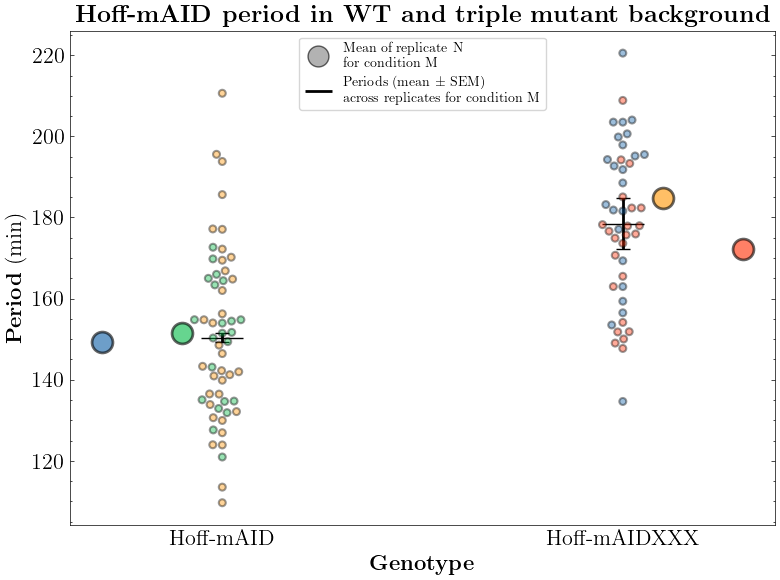

In [56]:
kwargs = {'title':r'\textbf{Hoff-mAID period in WT and triple mutant background}', 
          'title_fontsize':18, 
          'xlabel':r'\textbf{Genotype}',
          'xlabel_fontsize':16,
          'ylabel':r'\textbf{Period} (min)',
          'ylabel_fontsize':16,
          'xticks_fontsize':16,
          'yticks_fontsize':16,
          'save_path': 'bad_hoff-mAID.pdf'}
superplot(ridges_total.iloc[:,[0,2,3]], group_cols=['Condition','Exp'], category_order=['Hoff-mAID', 'Hoff-mAIDXXX'],measure_col=measure_col, **kwargs)

In [48]:
grouped_mean = ridges_total.groupby(['Exp', 'Condition']).agg({'periods':'mean'}).reset_index()
grouped_std = ridges_total.groupby(['Exp', 'Condition']).agg({'periods':'std'}).reset_index()
# grouped_sem = ridges_total.groupby(['Exp', 'Condition']).agg({'periods':'sem'})

In [49]:
hoff_maid_mean = grouped_mean.reset_index().loc[grouped_mean.reset_index()['Condition']=='Hoff-mAIDXXX', 'periods']

In [59]:
hoff_maid_std = grouped_std.reset_index().loc[grouped_std.reset_index()['Condition']=='Hoff-mAIDXXX', 'periods']

In [51]:
hoff_maid_std

0    20.421171
1    16.127982
Name: periods, dtype: float64

In [52]:
grouped_mean.reset_index().loc[grouped_mean.reset_index()['Condition']=='Hoff', 'periods'].std()

nan

In [146]:
grouped_mean

,Exp,Condition,periods
0,hoff-maidWT2,Hoff,NaN
1,hoff-maidWT2,Hoff-mAID,149.223776
2,hoff_hoff_mAID,Hoff,132.551681
3,hoff_hoff_mAID,Hoff-mAID,151.545471


In [121]:
grouped_std

,Exp,Condition,periods
0,hoff-maidWT2,Hoff,NaN
1,hoff-maidWT2,Hoff-mAID,14.723314
2,hoff_hoff_mAID,Hoff,29.441274
3,hoff_hoff_mAID,Hoff-mAID,24.218787


In [122]:
grouped_std['periods'].iloc[[1,3]]

1    14.723314
3    24.218787
Name: periods, dtype: float64

In [64]:
std_dev = np.sqrt(((hoff_maid_count1-1) * np.square(hoff_maid_std.iloc[0]) + (hoff_maid_count2-1) * np.square(hoff_maid_std.iloc[1]))/(hoff_maid_count1+hoff_maid_count2-2))

In [170]:
std_dev

np.float64(21.041596444822268)

In [69]:
ridges_total.loc[ridges_total['Condition']=='Hoff-mAID', 'periods'].mean()

nan

In [145]:
hoff_maid_mean.mean()

np.float64(150.38462322149832)

In [158]:
ridges_total.groupby(['Exp', 'Condition']).agg({'periods':'mean'}).reset_index()

C:\Users\pperez\AppData\Local\Temp\3\ipykernel_27116\4106329289.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ridges_total.groupby(['Exp', 'Condition']).agg({'periods':'mean'}).reset_index()


,Exp,Condition,periods
0,hoff-maidWT2,Hoff,NaN
1,hoff-maidWT2,Hoff-mAID,149.223776
2,hoff_hoff_mAID,Hoff,132.551681
3,hoff_hoff_mAID,Hoff-mAID,151.545471


In [62]:
hoff_maid_count2 = ridges_total.loc[(ridges_total['Exp']=='hoff_hoff_mAIDXXX') & (ridges_total['Condition']=='Hoff-mAIDXXX'), 'Signal'].count()

In [61]:
hoff_maid_count1 = ridges_total.loc[(ridges_total['Exp']=='hoff-maidXXX_injected') & (ridges_total['Condition']=='Hoff-mAIDXXX'), 'Signal'].count()

In [58]:
hoff_maid_count1

np.int64(23)

In [55]:
ridges_total['Exp'].unique()

array(['hoff_hoff_mAIDXXX', 'hoff-maidXXX_injected'], dtype=object)

In [63]:
grouped_std

,Exp,Condition,periods
0,hoff-maidXXX_injected,Hoff-mAIDXXX,20.421171
1,hoff_hoff_mAIDXXX,Hoff-mAIDXXX,16.127982
2,hoff_hoff_mAIDXXX,HoffXXX,23.676125


In [65]:
std_dev

np.float64(18.400218011382538)

In [66]:
grouped_mean

,Exp,Condition,periods
0,hoff-maidXXX_injected,Hoff-mAIDXXX,184.693431
1,hoff_hoff_mAIDXXX,Hoff-mAIDXXX,172.207209
2,hoff_hoff_mAIDXXX,HoffXXX,144.903152


In [67]:
grouped_mean['periods'].iloc[:2].mean()

np.float64(178.45032021454756)

In [71]:
hoff_maid_mean.sem()

np.float64(6.243111005231284)

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from scipy.stats import ttest_ind

def superplot(data, group_cols, measure_col, ttest=False, category_order=None, jitter_seed=None, jitter_strength=0.08, **kwargs):
    group_condition, group_replicate = group_cols

    # Reset index and ensure strings
    data = data.reset_index()
    data[group_condition] = data[group_condition].astype(str)
    data[group_replicate] = data[group_replicate].astype(str)

    # Category order
    if category_order is None:
        ordered_conditions = sorted(data[group_condition].unique())
    else:
        ordered_conditions = category_order
    data[group_condition] = pd.Categorical(data[group_condition], categories=ordered_conditions, ordered=True)

    # Remove empty groups
    data = data.groupby(group_cols, observed=True).filter(lambda g: len(g) > 0)

    # Replicate means
    replicate_averages = data.groupby(group_cols, as_index=False, observed=True).agg({measure_col: 'mean'})
    replicate_averages[group_condition] = replicate_averages[group_condition].astype(str)
    replicate_averages[group_condition] = pd.Categorical(replicate_averages[group_condition], categories=ordered_conditions, ordered=True)

    # Assign consistent colors
    unique_reps = sorted(data[group_replicate].unique())
    palette = sns.color_palette(n_colors=len(unique_reps))
    rep_to_color = dict(zip(unique_reps, palette))
    data['color'] = data[group_replicate].map(rep_to_color)
    replicate_averages['color'] = replicate_averages[group_replicate].map(rep_to_color)

    # Compute mean and SEM
    if data[group_replicate].nunique() == 1:
        condition_stats = replicate_averages.groupby(group_condition, observed=True).agg(
            mean_measure=(measure_col, 'mean'),
            sem_measure=(measure_col, lambda x: np.nan)
        ).reset_index()
    else:
        condition_stats = replicate_averages.groupby(group_condition, observed=True).agg(
            mean_measure=(measure_col, 'mean'),
            sem_measure=(measure_col, lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
        ).reset_index()

    condition_stats[group_condition] = pd.Categorical(condition_stats[group_condition], categories=ordered_conditions, ordered=True)

    # Plot
    with plt.style.context('science'):
        plt.figure(figsize=(8, 6))

        # Raw data
        sns.swarmplot(
            x=group_condition, y=measure_col, hue=group_replicate,
            data=data, size=5, edgecolor="k", linewidth=1.5, alpha=0.4,
            legend=False, palette=rep_to_color
        )

        # Add jittered x-positions for replicate averages
        condition_to_x = {condition: i for i, condition in enumerate(ordered_conditions)}
        # Get x positions as floats, then add jitter
        if jitter_seed is not None:
            np.random.seed(jitter_seed)
        replicate_averages['_x_jittered'] = replicate_averages[group_condition].astype(str).map(condition_to_x).astype(float)
        replicate_averages['_x_jittered'] += np.random.uniform(-jitter_strength, jitter_strength, size=len(replicate_averages))

        # Replicate average markers (large)
        plt.scatter(
            replicate_averages['_x_jittered'], replicate_averages[measure_col],
            s=300, edgecolor="k", linewidth=2, alpha=0.6,
            c=replicate_averages['color'], zorder=3
        )

        # Error bars (centered)
        for i, row in condition_stats.iterrows():
            err = row['sem_measure'] if not np.isnan(row['sem_measure']) else 0
            plt.errorbar(
                x=i, y=row['mean_measure'], yerr=err,
                fmt='_', color='black', capsize=5, elinewidth=2, markersize=30
            )

        # T-test annotation
        if ttest and len(ordered_conditions) == 2:
            try:
                cond1, cond2 = ordered_conditions
                vals1 = replicate_averages[replicate_averages[group_condition] == cond1][measure_col].values
                vals2 = replicate_averages[replicate_averages[group_condition] == cond2][measure_col].values
                stat, pval = ttest_ind(vals1, vals2, equal_var=False)
                y_max = data[measure_col].max() + 2
                plt.text(0.5, y_max, f"p = {pval:.4f}", ha='center', va='bottom', color='black')
            except Exception as e:
                print(f"Could not compute t-test: {e}")

        # Custom legend
        custom_dot = Line2D([], [], marker='o', color='w', markerfacecolor='gray',
                            markeredgecolor='k', markersize=15, linewidth=2, alpha=0.6)
        custom_sem_handle = Line2D([], [], marker='_', color='black', markersize=30, linewidth=2)
        plt.legend(
            [custom_dot, custom_sem_handle],
            [
                '\u00A0\u00A0\u00A0Mean of replicate N \nfor condition M',
                f'{measure_col.replace("_", " ").capitalize()} (mean ± SEM)\nacross replicates for condition M'
            ],
            loc='upper center',
            frameon=True,
            title=""
        )

        # Labels
        plt.xticks(fontsize=kwargs.get('xticks_fontsize', 14))
        plt.yticks(fontsize=kwargs.get('yticks_fontsize', 14))
        plt.xlabel(kwargs.get('xlabel', ''), fontsize=kwargs.get('xlabel_fontsize', 14))
        plt.ylabel(kwargs.get('ylabel', ''), fontsize=kwargs.get('ylabel_fontsize', 14))
        if 'title' in kwargs:
            plt.title(kwargs['title'], fontsize=kwargs.get('title_fontsize', 18))

        plt.tick_params(axis='x', bottom=False, top=False)
        plt.tick_params(axis='y', left=True, right=True)
        plt.grid(False)
        plt.tight_layout()

        if kwargs.get('save_path') is not None:
            plt.savefig(kwargs['save_path'])
        
        # Compute summary statistics to return
        pooled_std = data.groupby(group_condition, observed=True)[measure_col].std(ddof=1)
        all_values_mean = data.groupby(group_condition, observed=True)[measure_col].mean()
        replicate_mean = replicate_averages.groupby(group_condition, observed=True)[measure_col].mean()
        sem = replicate_averages.groupby(group_condition, observed=True)[measure_col].sem()
        n_individual = data.groupby(group_condition, observed=True)[measure_col].count()

        summary_df = pd.DataFrame({
            'mean_all_individuals': all_values_mean,
            'mean_replicate_averages': replicate_mean,
            'sem_replicate_averages': sem,
            'pooled_std': pooled_std,
            'n_individual_measurements': n_individual
        }).reset_index()
        
        plt.show()
        
        return summary_df


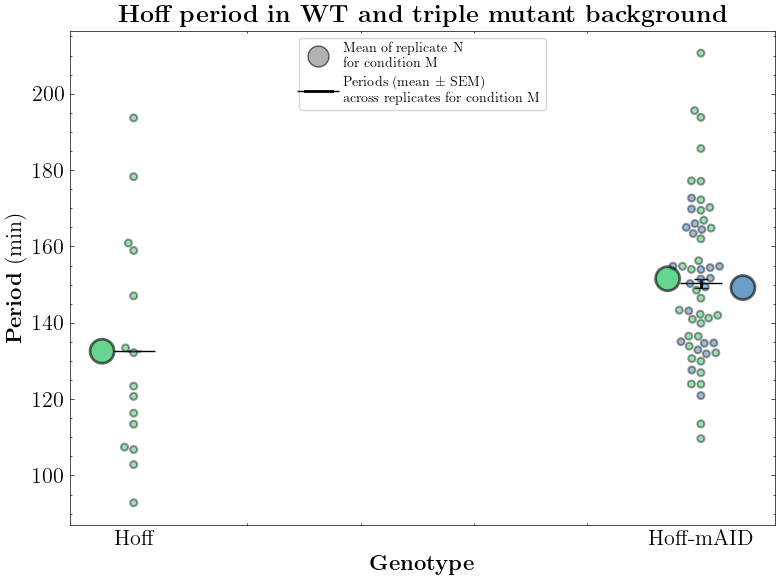

In [142]:
kwargs = {'title':r'\textbf{Hoff period in WT and triple mutant background}', 
          'title_fontsize':18, 
          'xlabel':r'\textbf{Genotype}',
          'xlabel_fontsize':16,
          'ylabel':r'\textbf{Period} (min)',
          'ylabel_fontsize':16,
          'xticks_fontsize':16,
          'yticks_fontsize':16,
          'save_path': None}
# superplot(ridges_total.iloc[:,[0,2,3]], group_cols=['Condition','Exp'], category_order=['Hoff-mAID', 'Hoff-mAIDXXX'],measure_col=measure_col, **kwargs)
summary_df = superplot(ridges_total, group_cols=['Condition','Exp'], category_order=['Hoff', 'Hoff-mAID'],measure_col=measure_col, jitter_seed=5, jitter_strength=0.10, **kwargs)

In [143]:
summary_df

,Condition,mean_all_individuals,mean_replicate_averages,sem_replicate_averages,pooled_std,n_individual_measurements
0,Hoff,132.551681,132.551681,NaN,29.441274,15
1,Hoff-mAID,150.633376,150.384623,1.160848,20.880801,56


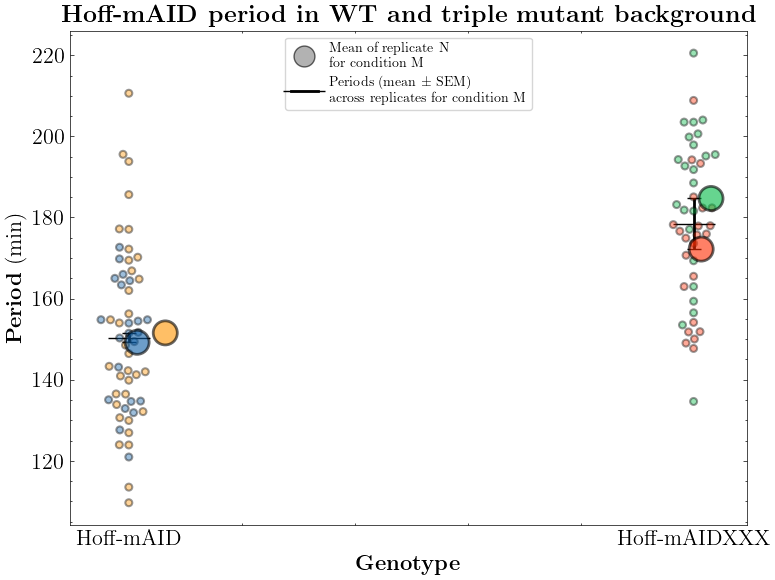

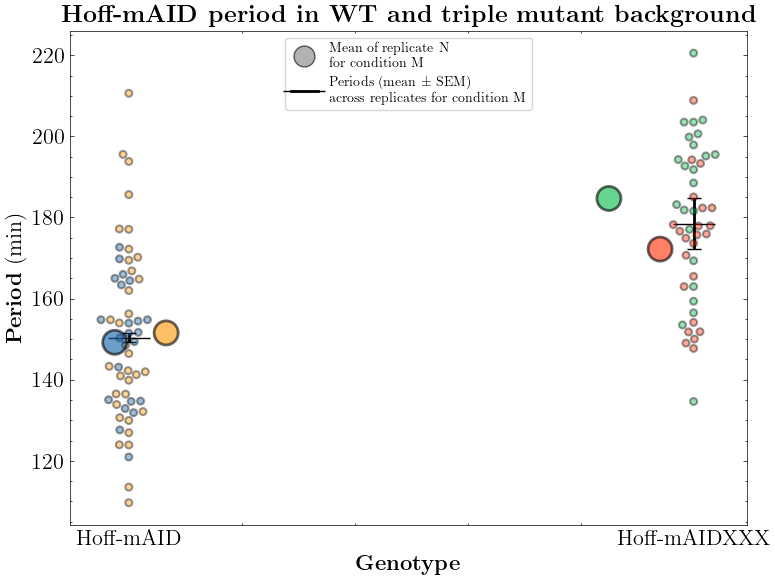

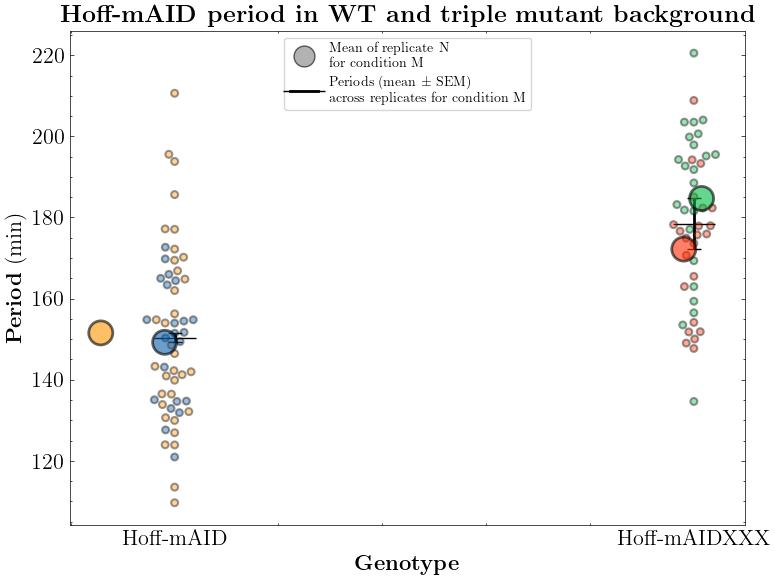

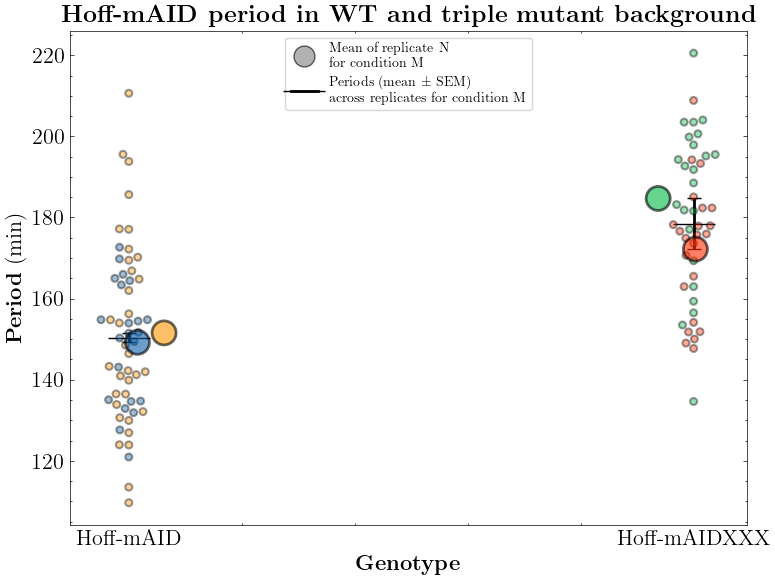

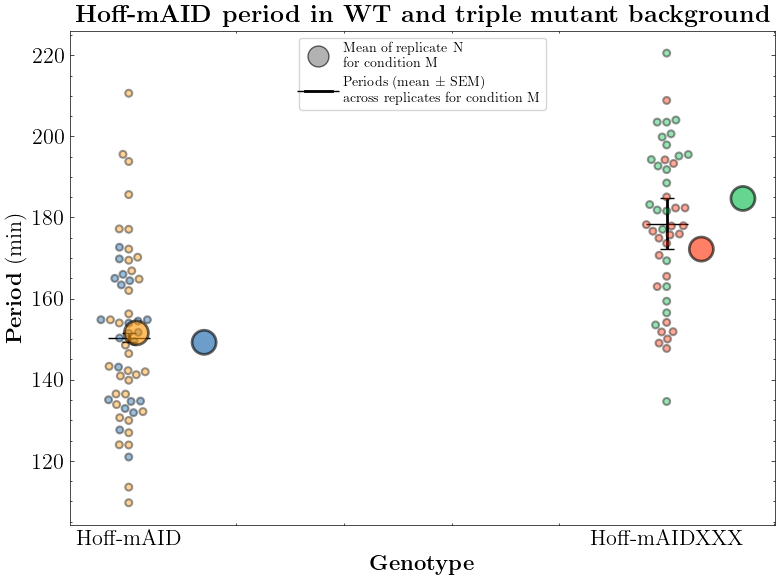

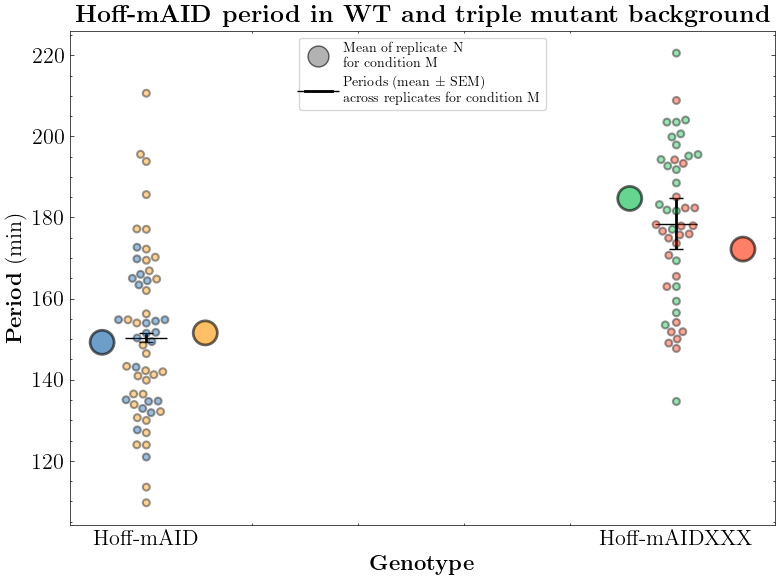

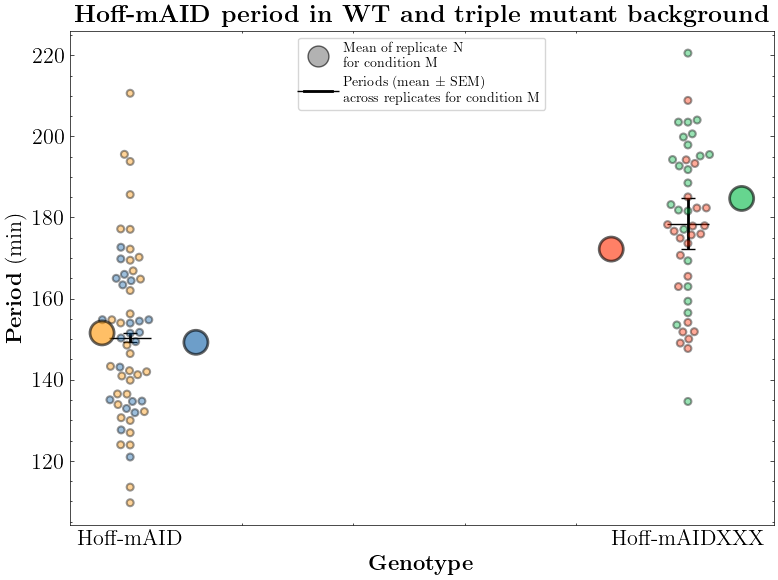

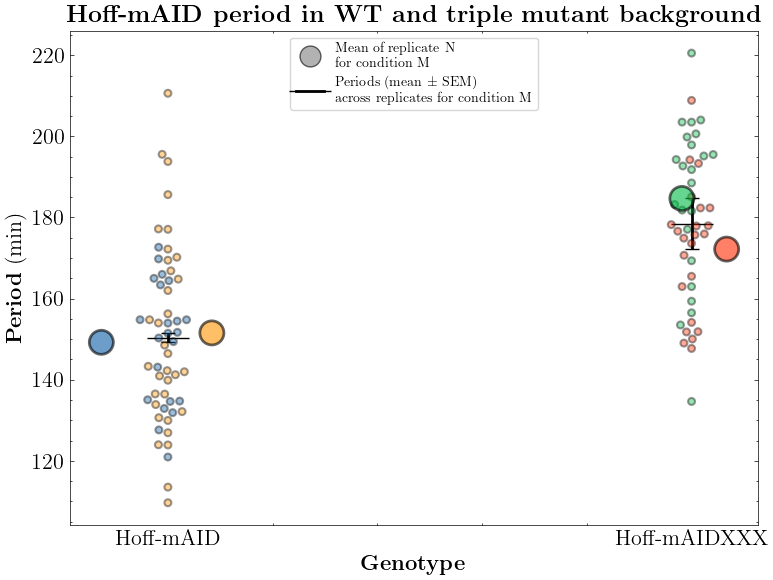

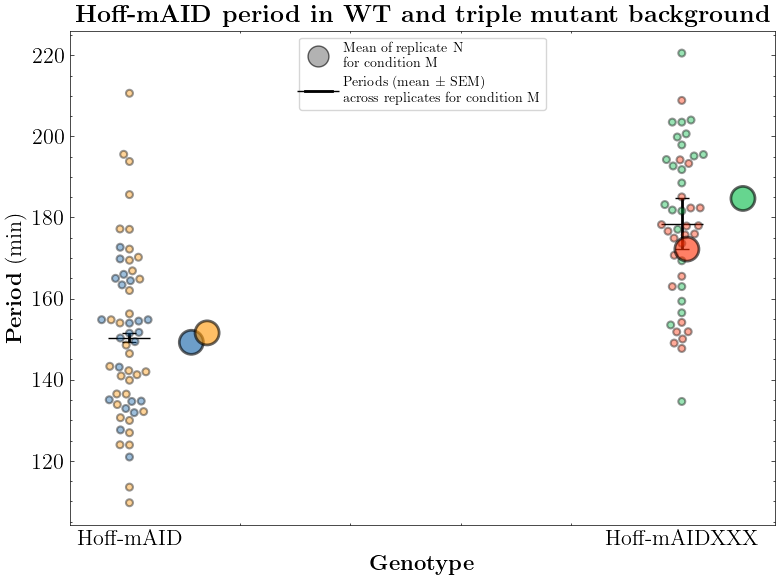

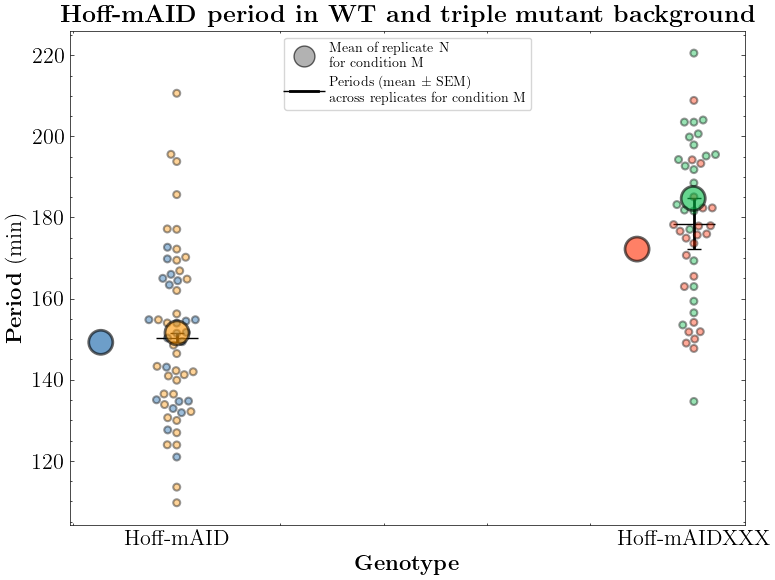

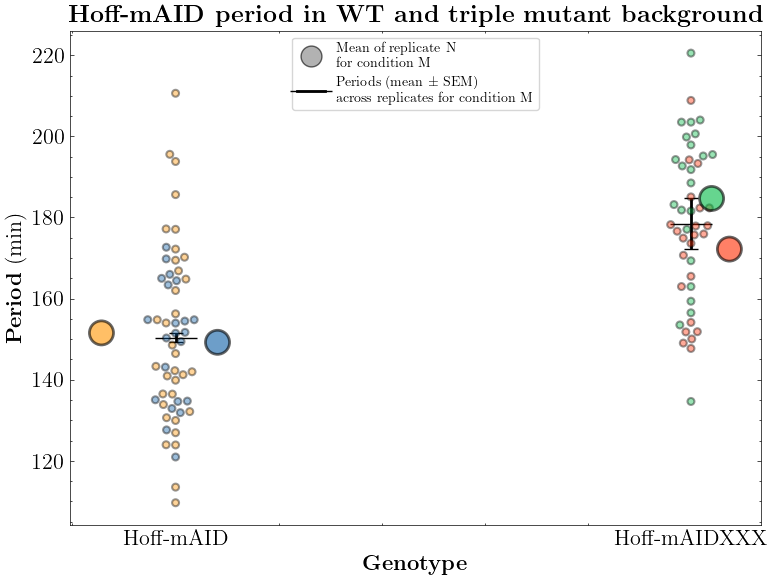

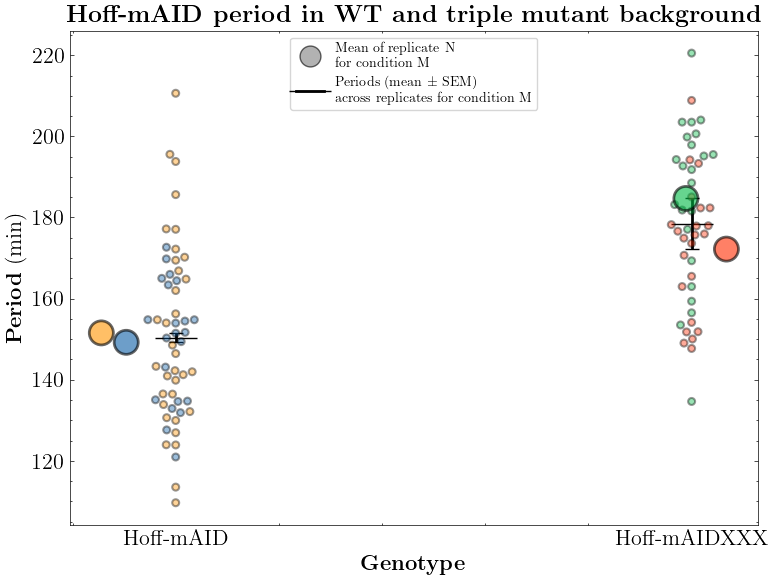

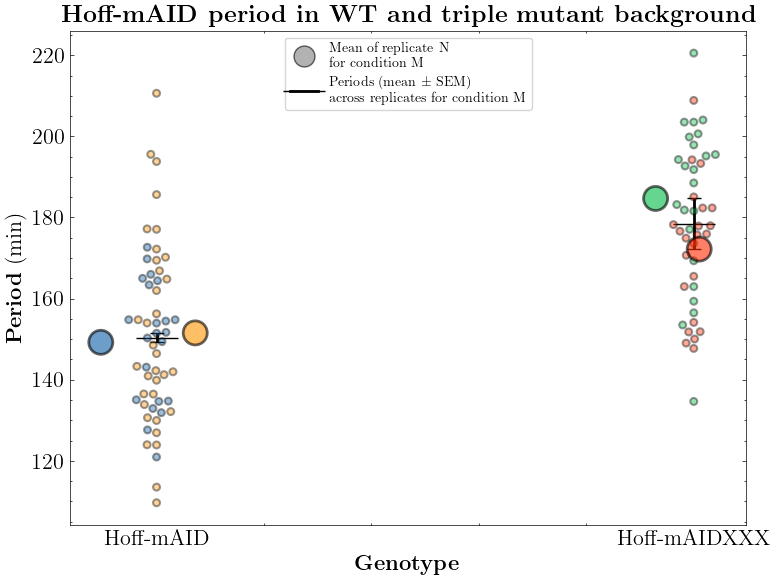

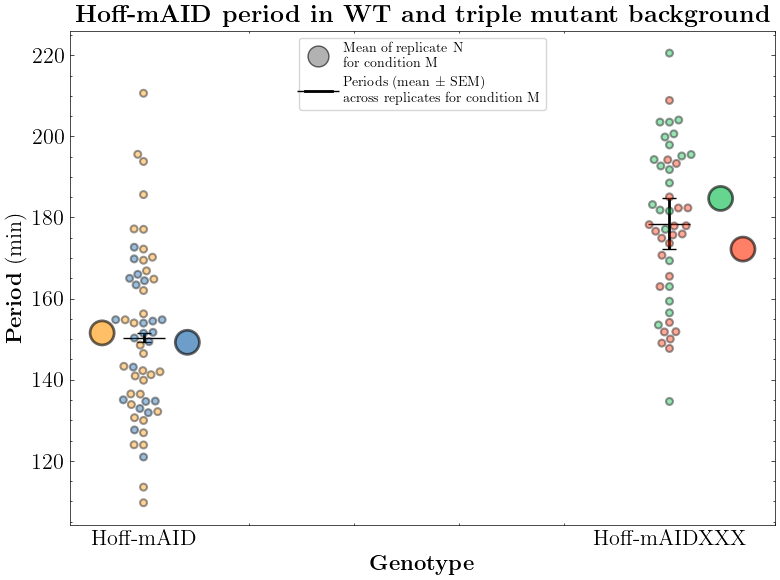

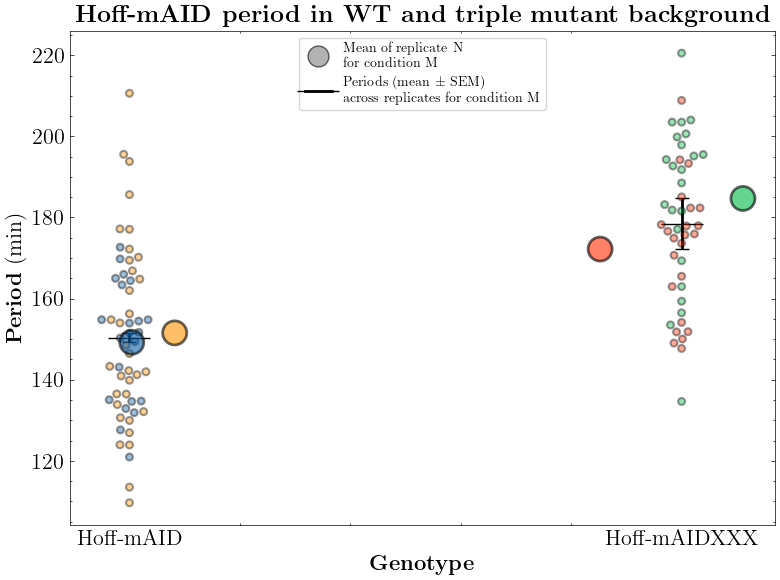

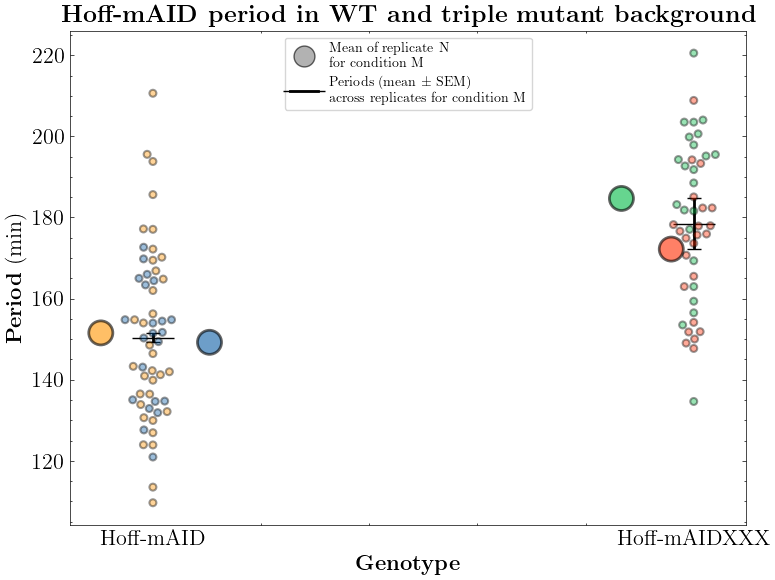

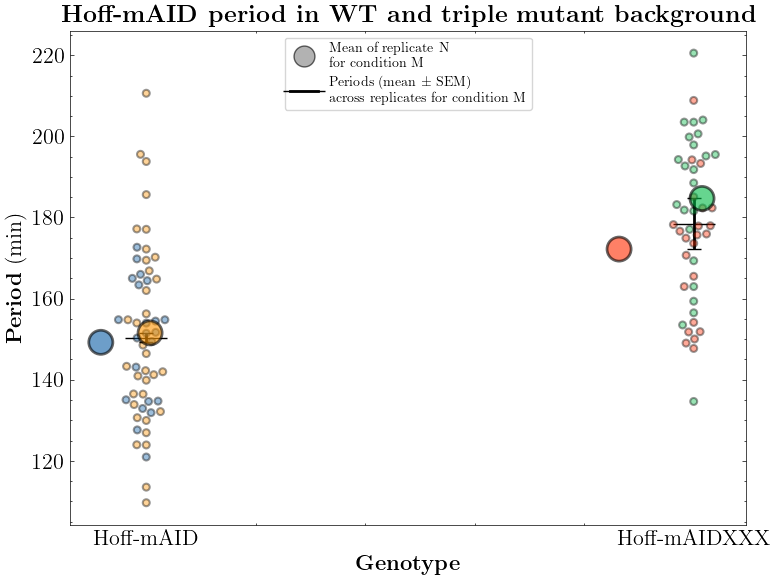

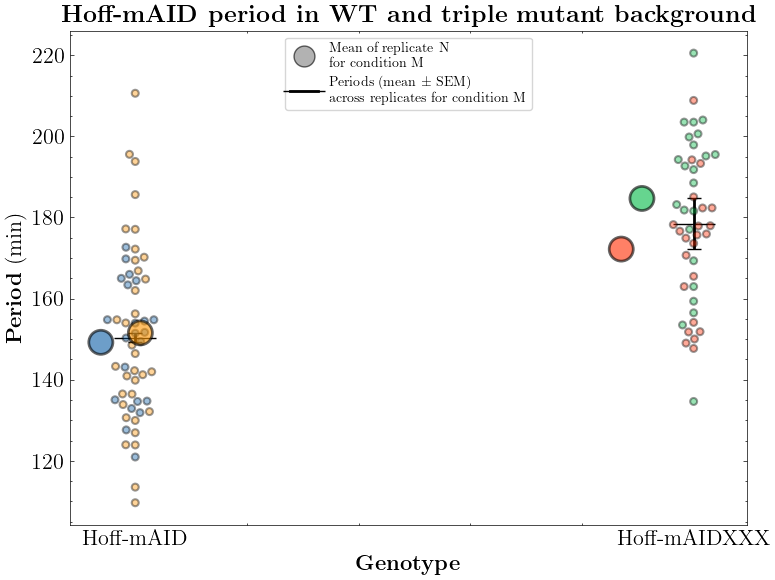

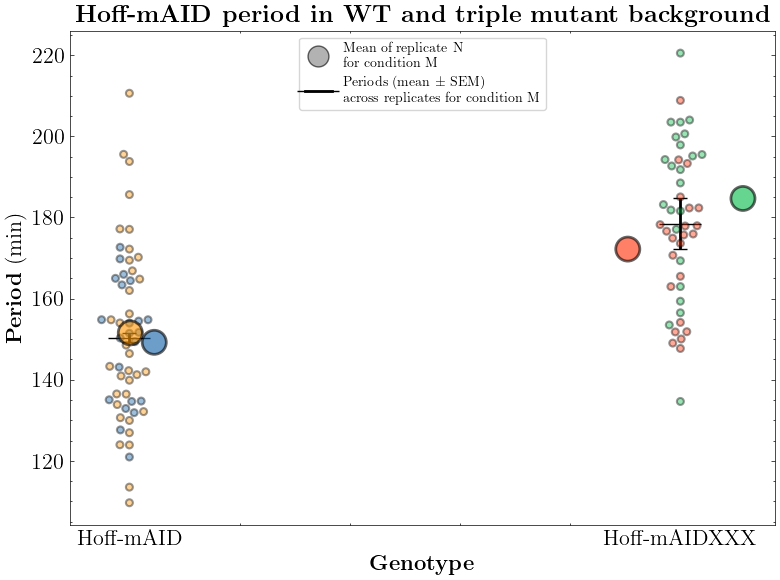

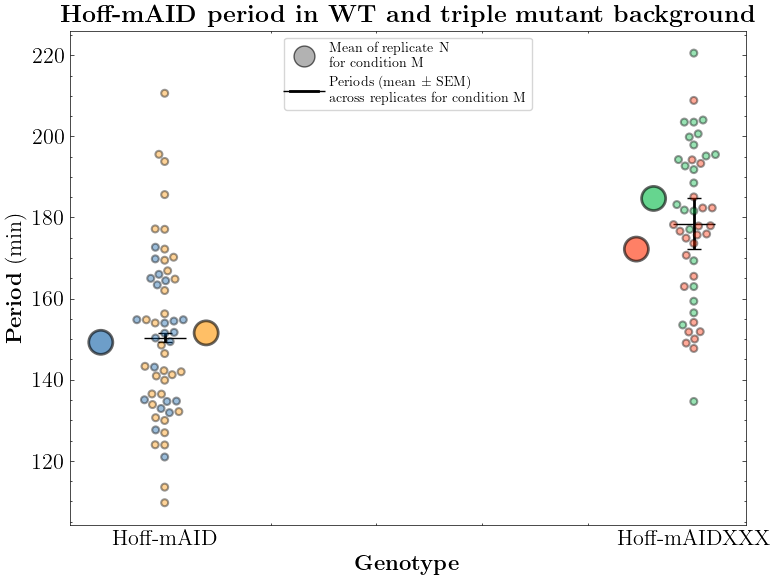

In [115]:
for jitter_seed in range(0,20,1):
    superplot(ridges_total, group_cols=['Condition','Exp'], category_order=['Hoff-mAID', 'Hoff-mAIDXXX'],measure_col=measure_col, jitter_seed=jitter_seed, jitter_strength=0.15, **kwargs)

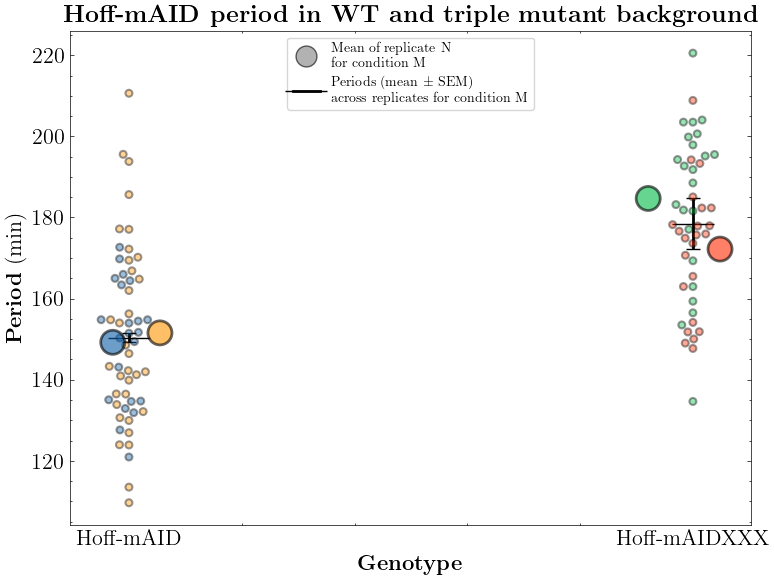

In [90]:
superplot(
    ridges_total[['periods', 'Exp', 'Condition']],  # make sure this includes measure_col and group_cols
    group_cols=['Condition', 'Exp'],
    category_order=['Hoff-mAID', 'Hoff-mAIDXXX'],
    measure_col='periods',
    **kwargs
)


In [37]:
ridges_total

,periods,Signal,Exp,Condition
0,197.890691,hoff-maidxxx_injected_xy002_1,hoff-maidXXX_injected,Hoff-mAIDXXX
1,200.625602,hoff-maidxxx_injected_xy003_1,hoff-maidXXX_injected,Hoff-mAIDXXX
2,199.848363,hoff-maidxxx_injected_xy004_0,hoff-maidXXX_injected,Hoff-mAIDXXX
3,134.637892,hoff-maidxxx_injected_xy004_1,hoff-maidXXX_injected,Hoff-mAIDXXX
4,156.497653,hoff-maidxxx_injected_xy005_0,hoff-maidXXX_injected,Hoff-mAIDXXX
...,...,...,...,...
129,185.074889,hoff-hoff-maid001xxx_xy103_0,hoff_hoff_mAIDXXX,Hoff-mAIDXXX
130,170.684685,hoff-hoff-maid001xxx_xy103_1,hoff_hoff_mAIDXXX,Hoff-mAIDXXX
131,208.865122,hoff-hoff-maid001xxx_xy104_0,hoff_hoff_mAIDXXX,Hoff-mAIDXXX
132,175.701377,hoff-hoff-maid001xxx_xy109_0,hoff_hoff_mAIDXXX,Hoff-mAIDXXX


In [44]:
superplot(
    ridges_total[['periods', 'Condition', 'Exp']],  # keep order consistent with group_cols
    group_cols=['Condition', 'Exp'],
    category_order=['Hoff-mAID', 'Hoff-mAIDXXX'],
    measure_col='periods',
    **kwargs
)


C:\Users\pperez\AppData\Local\Temp\3\ipykernel_38928\849176372.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  replicate_averages = data.groupby(group_cols, as_index=False).agg({measure_col: 'mean'})


ValueError: Length of values (6) does not match length of index (16)

In [47]:
ridges_total['Exp'].unique()

array(['hoff-maidXXX_injected', 'hoff-maidWT2', 'hoff_hoff_mAID',
       'hoff_hoff_mAIDXXX'], dtype=object)

In [48]:
ridges_total['Condition'].unique()

array(['Hoff-mAIDXXX', 'Hoff-mAID', 'Hoff', 'HoffXXX'], dtype=object)